In [1]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt

from bayspecdec.spectrum_gen import *
import bayspecdec as bsd

from functools import partial

In [2]:
import jupyter_black

jupyter_black.load()

In [3]:
Array = np.ndarray[tuple[int], np.dtype(np.float32)]

In [4]:
BIN_SIZE: float = 1e-1
MIN: float = 0
MAX: float = 12

In [5]:
DET_AX: Array = np.arange(MIN, MAX, BIN_SIZE)
PEAK: Array = np.zeros_like(DET_AX)
PEAK += lorentzian(DET_AX, 6, 0.5, 1)

In [6]:
SIGNAL: Array = np.zeros_like(DET_AX)
SIGNAL[bin_idx(DET_AX, 3)] += 1
SIGNAL[bin_idx(DET_AX, 6)] += 2
SIGNAL[bin_idx(DET_AX, 10)] += 2
# SIGNAL[bin_idx(DET_AX, 6)] += 2

BLURRED: Array = sp.signal.convolve(SIGNAL, PEAK, mode="full")[
    len(DET_AX) // 2 : -len(DET_AX) // 2 + 1
]

# y = draw_spectrum(BLURRED, dose=1_000_000).astype(np.float64)
# y /= y.max()

y_norm = np.random.normal(loc=BLURRED, scale=0.01)
y_pois = np.random.poisson(lam=BLURRED * 10)

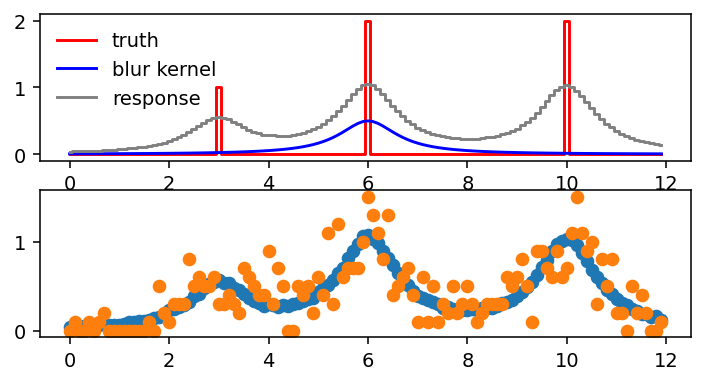

In [7]:
fig, (tax, bax) = plt.subplots(nrows=2)

tax.step(DET_AX, SIGNAL, where="mid", label="truth", color="red")
tax.plot(DET_AX, PEAK, label="blur kernel", color="blue")
tax.step(DET_AX, BLURRED, where="mid", label="response", color="gray")
tax.legend(frameon=False)


bax.scatter(DET_AX, y_norm)
bax.scatter(DET_AX, y_pois / 10)

fig.set_size_inches(6, 3)
fig.set_dpi(140)

In [8]:
from typing import Iterable


class BlurKernel:
    name: str = "BlurKernel"
    n_parameters_per_basis: int = 1

    def evaluate(self, x: Array, params: Iterable[Array]) -> Array:
        (μ,) = params
        evals = []
        for μi in μ:
            peak = lorentzian(x, μi, 0.5, 1)
            peak /= peak.max()
            evals.append(peak)
        return np.stack(evals)

In [9]:
from numba.experimental.jitclass.decorators import jitclass


class Parameterization:
    def __init__(self, K: int):
        self.K = K
        self.ndim = 2 * K

    def pack(self, structured: tuple[Array, Array, Array]) -> Array:
        I, μ = structured
        θ = np.empty(self.ndim)
        θ[: self.K] = I
        θ[self.K : 2 * self.K] = μ
        # θ[2 * self.K :] = σ
        return θ

    def unpack(self, θ: Array) -> tuple[Array, Array, Array]:
        I: Array = θ[..., : self.K]
        μ: Array = θ[..., self.K : 2 * self.K]
        # σ: Array = θ[..., 2 * self.K :]
        return (I, μ)  # , σ)

    def to_z(self, θ: Array) -> Array:
        z = θ.copy()
        # z[..., : self.K] = np.log(z[..., : self.K])
        return z

    def from_z(self, z: Array) -> Array:
        θ = z.copy()
        # θ[..., : self.K] = np.exp(θ[..., : self.K])
        return θ

    def log_jacobian(self, θ: Array) -> float:
        return 1
        I, μ, σ = self.unpack(θ)
        return float(np.sum(np.log(I)) + np.sum(np.log(θ)))

In [10]:
class LorentzPrior:
    def __init__(self, amplitudes, centers):  # , widths):
        self.amplitudes = amplitudes
        self.centers = centers
        # self.widths = widths

    def sample(self, rng, parameterization) -> Array:
        K: int = parameterization.K
        I: Array = self.amplitudes.sample(rng, K)
        μ: Array = self.centers.sample(rng, K)
        # σ: Array = self.widths.sample(rng, K)
        # print(f"I: {I}, μ: {μ}, σ: {σ}")
        # for Ii, μi, σi in zip(I, μ, σ):
        #     plt.plot(lorentzian(DET_AX, μi, σi, Ii))
        # plt.show()
        return parameterization.pack((I, μ))

    def log_prob(self, θ, parameterization) -> float:
        I, μ = parameterization.unpack(θ)
        lp_I = np.sum(self.amplitudes.log_prob(I))
        lp_μ = np.sum(self.centers.log_prob(μ))
        # lp_σ = np.sum(self.widths.log_prob(σ))
        return float(lp_I + lp_μ)  # + lp_σ)

In [11]:
lorentz_prior = LorentzPrior(
    amplitudes=bsd.UniformPrior(0.2, 1.2),
    centers=bsd.UniformPrior(1, 11),
    # widths=bsd.GammaPrior(5, 8),
)

In [12]:
betas = bsd.beta_schedule(36)

In [13]:
K = 3

normal_model = bsd.SpectralModel(
    x=DET_AX,
    y=y_pois,
    basis=BlurKernel(),
    prior=lorentz_prior,
    likelihood=bsd.GaussianNoise(sigma2=1e-4),
    parameterization=Parameterization(K=K),
)


hmc_sampler = bsd.ParallelTempering(
    model=normal_model,
    betas=betas,
    rng=np.random.default_rng(),
    kernel_factory=lambda model, beta, rng: bsd.hmc_kernel_factory(model, beta, rng),
)

In [14]:
result = hmc_sampler.run(burn_in=10, samples=100)

100%|███████████████████████████████████████████████████████████████████| 100/100 [00:13<00:00,  7.44it/s]


In [15]:
I, μ = Parameterization(K=3).unpack(result.samples_by_temperature[-1])
sort_key = np.argsort(μ, axis=1)
μ = np.take_along_axis(μ, indices=sort_key, axis=1)
I = np.take_along_axis(I, indices=sort_key, axis=1)
μ_ = np.mean(μ, axis=0)
I_ = np.mean(I, axis=0)
print(I_.shape)

(3,)


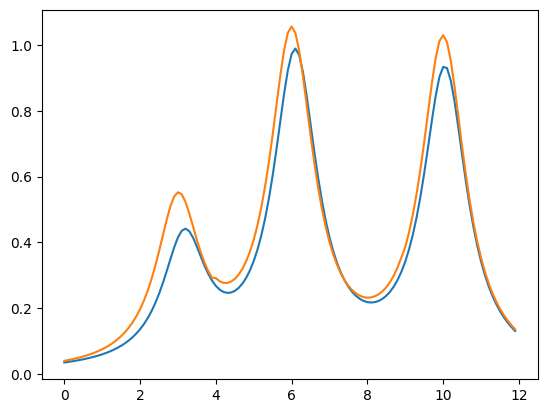

In [16]:
plt.plot(DET_AX, (I_[:, None] * BlurKernel().evaluate(DET_AX, (μ_,))).sum(axis=0) / 10)
plt.plot(DET_AX, BLURRED)

 10%|███████                                                               | 1/10 [00:00<00:01,  6.68it/s]/home/jeroensangers/Virtual-environments/SSA/lib/python3.11/site-packages/bayspecdec/likelihoods.py:83: RuntimeWarning: invalid value encountered in log
  log_likelihood = np.sum(y * np.log(prediction) - prediction - gammaln(y + 1.0))
100%|███████████████████████████████████████████████████████████████████| 100/100 [00:16<00:00,  5.94it/s]


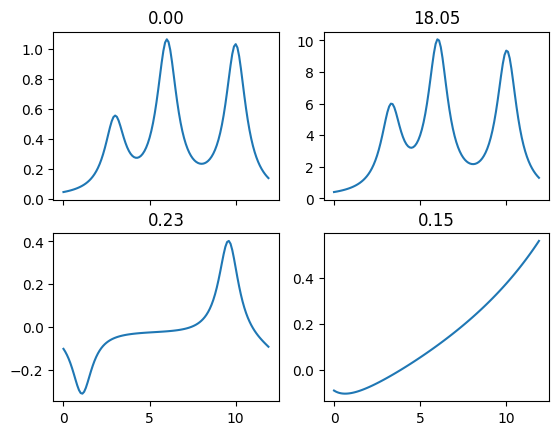

In [34]:
def rounded_eval(self, x: Array, params: Iterable[Array]) -> Array:
    (μ,) = params
    evals = []
    for μi in μ:
        peak = lorentzian(x, μi, 0.5, 1)
        peak /= peak.max()
        evals.append(peak)
    return np.ceil(np.stack(evals)).astype("int")


def mse(outcome):
    return np.mean((outcome - BLURRED) ** 2)


def calc_sig(θ):
    I, μ = Parameterization(K=K).unpack(θ)
    sort_key = np.argsort(μ, axis=1)
    μ = np.take_along_axis(μ, indices=sort_key, axis=1)
    I = np.take_along_axis(I, indices=sort_key, axis=1)
    μ_ = np.mean(μ, axis=0)
    I_ = np.mean(I, axis=0)
    return (I_[:, None] * BlurKernel().evaluate(DET_AX, (μ_,))).sum(axis=0)


fig, axes = plt.subplots(nrows=2, ncols=2, sharex=True)


for i, nmodel in enumerate([bsd.GaussianNoise(sigma2=1e-4), bsd.PoissonNoise()]):
    kernel = BlurKernel()
    div = 1
    if isinstance(nmodel, bsd.PoissonNoise):
        kernel.evaluate = lambda x, params: rounded_eval(kernel, x, params)
        div = 10
        signal = np.ceil(signal * 10)
    for j, signal in enumerate([y_norm, y_pois]):
        model = bsd.SpectralModel(
            x=DET_AX,
            y=signal,
            basis=kernel,
            prior=lorentz_prior,
            likelihood=nmodel,
            parameterization=Parameterization(K=K),
        )

        hmc_sampler = bsd.ParallelTempering(
            model=model,
            betas=betas,
            rng=np.random.default_rng(),
            kernel_factory=lambda model, beta, rng: bsd.hmc_kernel_factory(
                model, beta, rng
            ),
        )

        result = hmc_sampler.run(burn_in=10, samples=100)
        θ = result.samples_by_temperature[-1]
        signal = calc_sig(θ) / div
        mserr = mse(signal)

        ax = axes[i, j]
        ax.plot(DET_AX, signal)
        ax.set_title(f"{mserr:.2f}")

In [18]:
y_pois

array([ 0,  1,  0,  0,  1,  0,  1,  2,  0,  0,  0,  0,  0,  0,  0,  0,  1,
        0,  5,  2,  1,  3,  3,  3,  8,  5,  6,  5,  5,  6,  3,  3,  4,  3,
        2,  7,  6,  5,  4,  4,  9,  3,  7,  5,  0,  0,  5,  4,  5,  2,  6,
        4, 11,  3, 12,  6,  7,  7,  7, 10, 15, 13, 11,  8, 13,  4,  5,  6,
        7,  4,  1,  6,  1,  5,  1,  3,  2,  5,  2,  3,  5,  3,  1,  2,  3,
        3,  3,  3,  6,  5,  6,  8,  5,  1,  9,  9,  7,  6,  9,  6,  7, 11,
       15, 11,  9, 10,  3,  8,  5,  8,  2,  2,  0,  5,  2,  4,  2,  0,  0,
        1])